## Section 14
### Revisiting Pandas Plotting

* 125: A Pandas Plotting Recap
* 126: Changing Pandas Plot Styles
* 127: Adding Labels and Title to Pandas Plots
* 128: Using rename() When Plotting
* 129: Closer Look at Pandas Bar Plots
* 130: Challenge 1
* 131: Pandas Histograms
* 132: Box Plot
* 133: Pandas Line Plots
* 134: Challenge 2
* 135: Pandas Scatter Plots
* 136: Multiple Plots on the Same Axes
* 137: UFOs Plotting Challenge
* 138: Challenge 3
* 139: Pandas Automatic Subplots
* 140: Manual Subplots With Pandas
* 141: Challenge 4
* 142: Challenge 5
* 143: Exporting Figures with savefig()


125 - A Pandas Plotting Recap

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
titanic = pd.read_csv('../datasets/data/titanic.csv')
titanic['age'] = pd.to_numeric(titanic.age, errors='coerce')

In [101]:
houses = pd.read_csv('../datasets/data/kc_house_data.csv')

In [102]:
ufos = pd.read_csv('../datasets/data/nuforc_reports.csv', parse_dates=['date_time', 'posted'])

<Axes: xlabel='sex'>

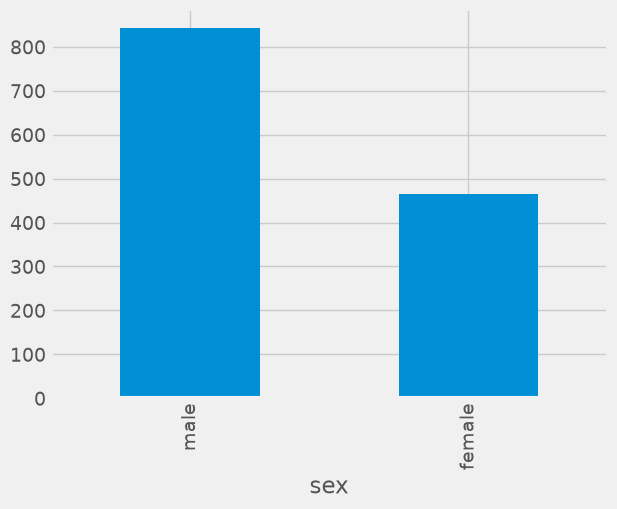

In [103]:
titanic.sex.value_counts().plot(kind='bar')

<Axes: >

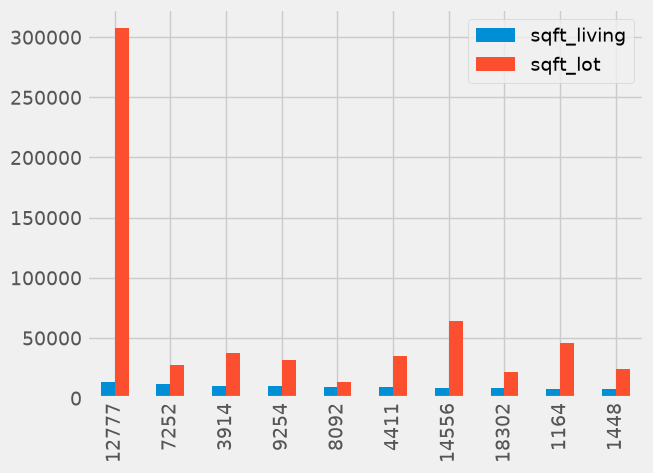

In [104]:
houses[['sqft_living', 'sqft_lot']].sort_values('sqft_living', ascending=False).head(10).plot(kind='bar')

126: Changing Pandas Plot Styles

In [105]:
plt.style.use('fivethirtyeight')

<Axes: xlabel='sex'>

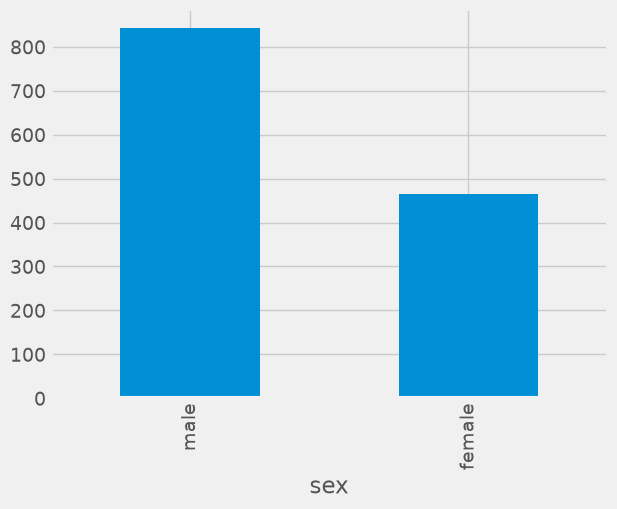

In [106]:
titanic.sex.value_counts().plot(kind='bar')

127: Adding Labels and Titles to Pandas Plots

<Axes: title={'center': 'Sex Breakdown'}, xlabel='sex'>

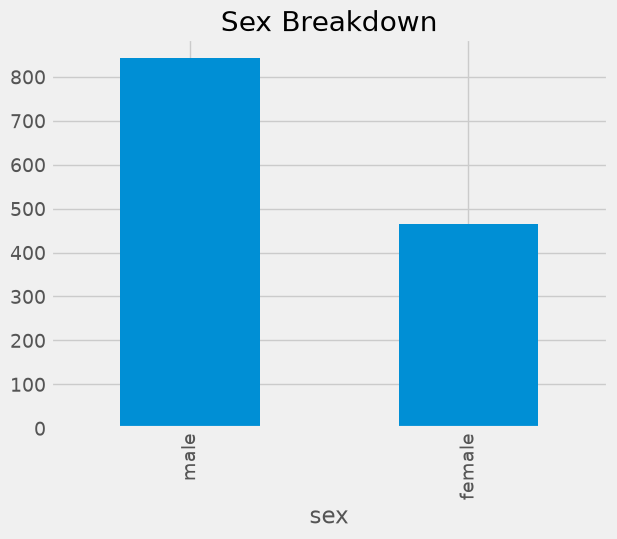

In [107]:
titanic.sex.value_counts().plot(kind='bar', title='Sex Breakdown')

Text(0.5, 1.0, 'Sex Breakdown')

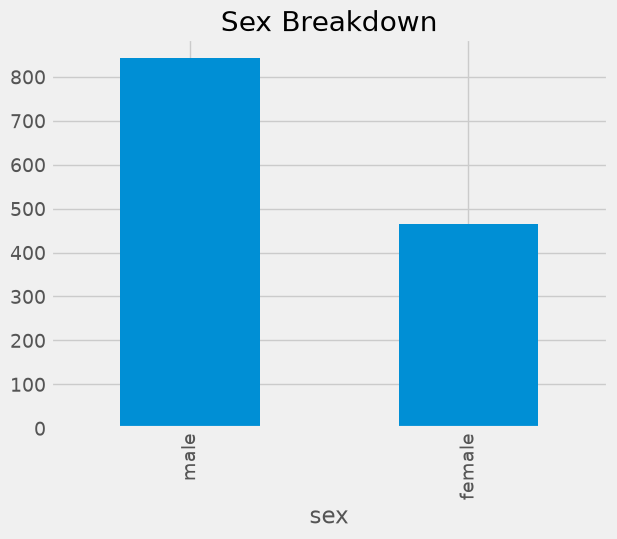

In [108]:
titanic.sex.value_counts().plot(kind='bar')
plt.title('Sex Breakdown')

In [109]:
ufos['month'] = ufos['date_time'].dt.month

<Axes: title={'center': 'UFOs Sightings by Month'}, xlabel='Month', ylabel='Sightings'>

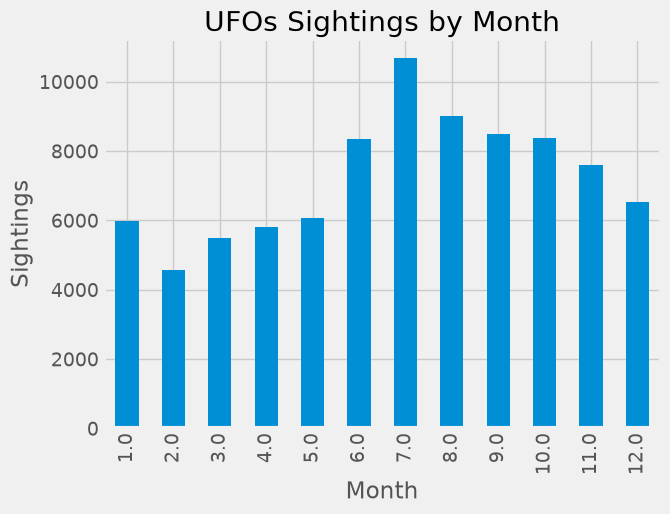

In [110]:
ufos.month.value_counts().sort_index().plot(kind='bar',
                                            title='UFOs Sightings by Month', 
                                            xlabel='Month',
                                            ylabel='Sightings')

Text(0, 0.5, 'Sightings')

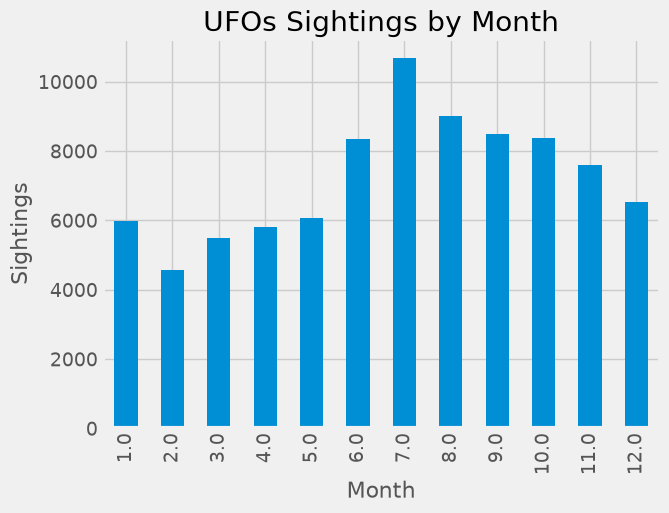

In [111]:
ufos.month.value_counts().sort_index().plot(kind='bar', title='UFOs Sightings by Month')
plt.xlabel('Month', fontsize=16)
plt.ylabel('Sightings', fontsize=16)

128: Using rename() When Plotting

In [112]:
sightings = ufos.month.value_counts().sort_index()
sightings

month
1.0      5979
2.0      4559
3.0      5494
4.0      5817
5.0      6063
6.0      8357
7.0     10682
8.0      8997
9.0      8498
10.0     8371
11.0     7596
12.0     6525
Name: count, dtype: int64

In [113]:
month_name = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
              7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
sightings.rename(month_name)

month
Jan     5979
Feb     4559
Mar     5494
Apr     5817
May     6063
Jun     8357
Jul    10682
Aug     8997
Sep     8498
Oct     8371
Nov     7596
Dec     6525
Name: count, dtype: int64

<Axes: xlabel='month'>

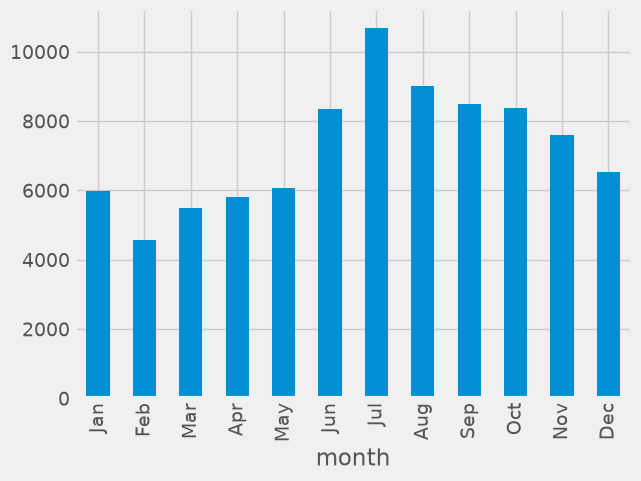

In [114]:
sightings.rename(month_name).plot(kind='bar')

Text(0, 0.5, 'Sightings')

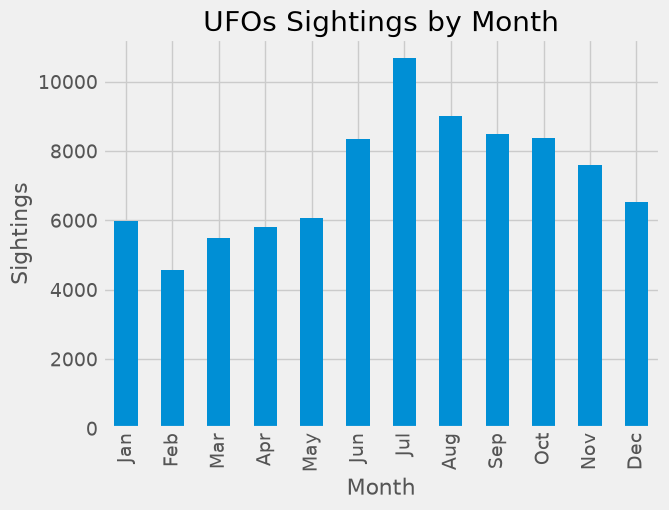

In [115]:
sightings.rename(month_name).plot(
    kind='bar', title='UFOs Sightings by Month')
plt.xlabel('Month', fontsize=16)
plt.ylabel('Sightings', fontsize=16)

129: Closer look at Pandas Bar Plots

In [116]:
salaries = pd.read_csv("../datasets/data/Salaries.csv", low_memory=False)

In [117]:
salaries["BasePay"] = pd.to_numeric(
    salaries["BasePay"], errors="coerce").fillna(0)
salaries["OvertimePay"] = pd.to_numeric(
    salaries["OvertimePay"], errors="coerce").fillna(0)
salaries["OtherPay"] = pd.to_numeric(
    salaries["OtherPay"], errors="coerce").fillna(0)

In [118]:
salaries.info()

<class 'pandas.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  str    
 2   JobTitle          148654 non-null  str    
 3   BasePay           148654 non-null  float64
 4   OvertimePay       148654 non-null  float64
 5   OtherPay          148654 non-null  float64
 6   Benefits          112495 non-null  str    
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  str    
 12  Status            38119 non-null   str    
dtypes: float64(6), int64(2), str(5)
memory usage: 14.7 MB


In [119]:
df = salaries[['EmployeeName', 'BasePay', 'OvertimePay', 'OtherPay']]

In [120]:
df.set_index('EmployeeName', inplace=True)

<Axes: xlabel='EmployeeName'>

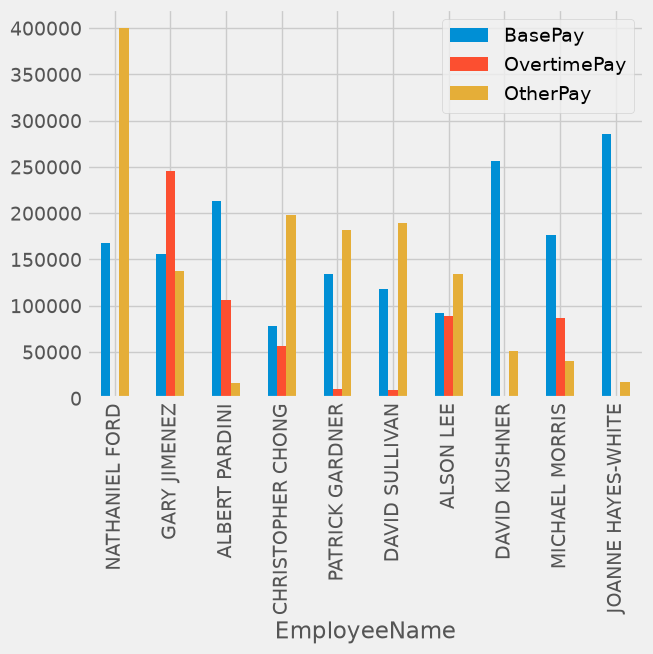

In [121]:
df.head(10).plot(kind='bar')

<Axes: ylabel='EmployeeName'>

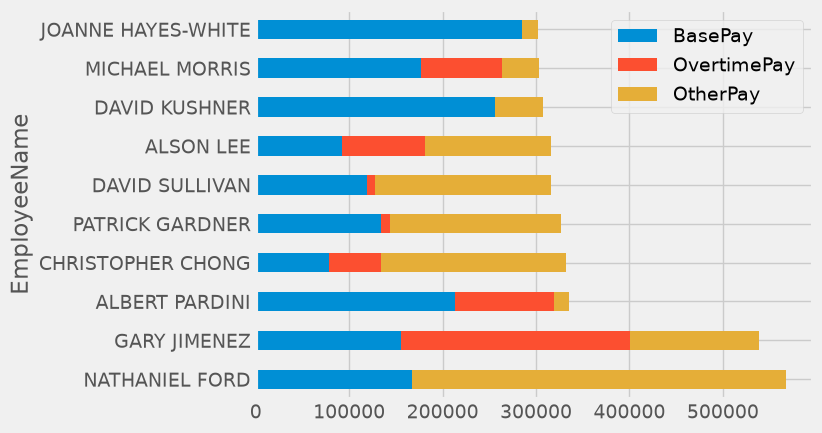

In [123]:
df.head(10).plot(kind='barh', stacked=True)

<Axes: xlabel='EmployeeName'>

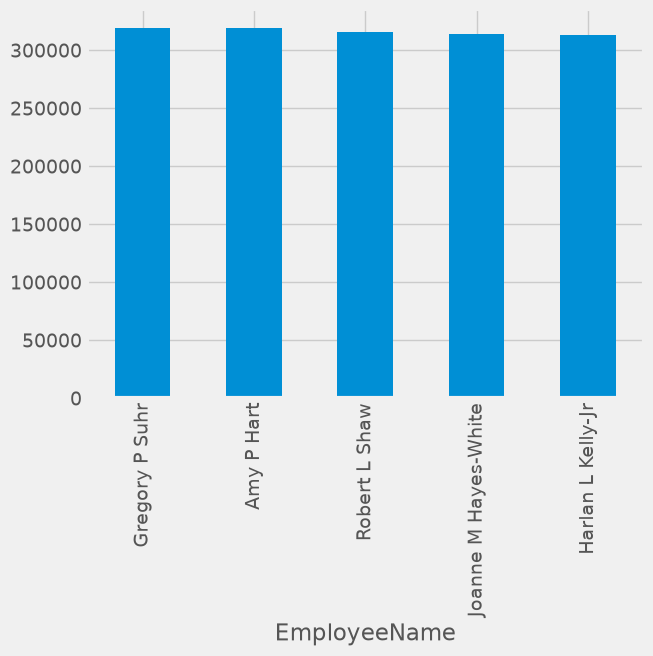

In [124]:
df.BasePay.sort_values(ascending=False).head().plot.bar()

Text(0.5, 0, 'USD')

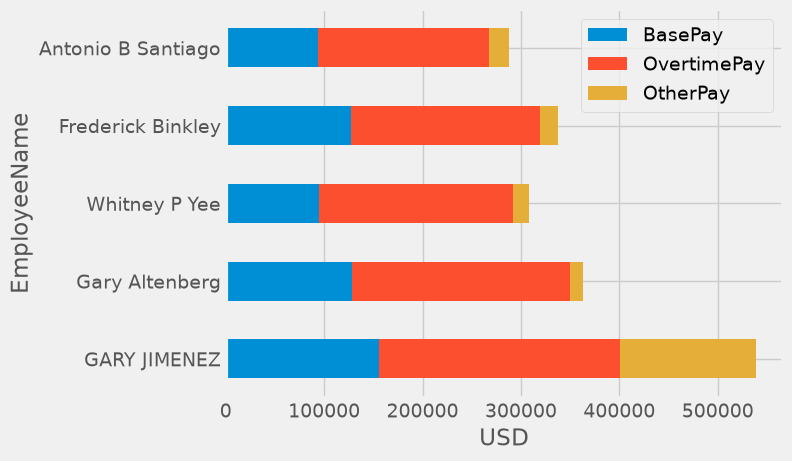

In [126]:
df.sort_values('OvertimePay', ascending=False).head().plot.barh(stacked=True)
plt.xlabel('USD')